In [1]:
!pip install focal-loss

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, applications, callbacks
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import os
from focal_loss import SparseCategoricalFocalLoss
import gc

2025-12-28 18:49:41.086866: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766947781.107752   18745 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766947781.114253   18745 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
SEED = 24520152

In [4]:
tf.keras.utils.set_random_seed(SEED)

In [5]:
TRAIN_DIR = '/kaggle/input/5-fold-brain-tumor-contrast-enhanced/kfold_dataset'
TRAIN_DIR

'/kaggle/input/5-fold-brain-tumor-contrast-enhanced/kfold_dataset'

In [6]:
SAVE_DIR = '/kaggle/working/'
SAVE_DIR

'/kaggle/working/'

In [7]:
CLASS_NAMES = sorted([d for d in os.listdir(os.path.join(TRAIN_DIR, 'Subset_1')) if os.path.isdir(os.path.join(TRAIN_DIR, 'Subset_1', d))])
CLASS_NAMES

['Glioma Tumor', 'Meningioma Tumor', 'Pituitary Tumor']

In [8]:
model_name = 'DenseNet121'
model_name

'DenseNet121'

In [9]:
preprocess_fn = applications.densenet.preprocess_input

In [10]:
def build_data_augmentation():
    """Create a simple data augmentation pipeline"""
    return tf.keras.Sequential([
        layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.1),
        layers.RandomBrightness(0.1),
    ], name='data_augmentation')

In [11]:
def get_data_for_fold(k, preprocess_fn, train_dir=TRAIN_DIR, IMG_SIZE=(224, 224), BATCH_SIZE=32, SEED=24520152):
    val_dir = os.path.join(train_dir, f'Subset_{k}')
    train_dirs = [os.path.join(train_dir, f'Subset_{i}') for i in range(1, 6) if i != k]
    
    val_ds = tf.keras.utils.image_dataset_from_directory(
        val_dir,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False,
        seed=SEED,
    )
    
    train_ds = tf.keras.utils.image_dataset_from_directory(
        train_dirs[0],
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=SEED,
    )
    
    for directory in train_dirs[1:]:
        ds_part = tf.keras.utils.image_dataset_from_directory(
            directory,
            image_size=IMG_SIZE,
            batch_size=BATCH_SIZE,
            shuffle=True,
            seed=SEED,
        )
        train_ds = train_ds.concatenate(ds_part)

    train_ds = train_ds.shuffle(buffer_size=3000, seed=SEED)
    
    AUTOTUNE = tf.data.AUTOTUNE
    data_augmentation = build_data_augmentation()

    def augment_and_preprocess_train(image, label):
        """Apply augmentation and preprocessing to the training set"""
        image = data_augmentation(image, training=True)
        image = preprocess_fn(image)
        return image, label

    def preprocess_val(image, label):
        """Apply preprocessing to the validation set (no augmentation)"""
        image = preprocess_fn(image)
        return image, label

    train_ds = train_ds.map(augment_and_preprocess_train, num_parallel_calls=AUTOTUNE).prefetch(buffer_size=AUTOTUNE)
    val_ds = val_ds.map(preprocess_val, num_parallel_calls=AUTOTUNE).prefetch(buffer_size=AUTOTUNE)

    return train_ds, val_ds

In [12]:
def build_densenet121(INPUT_SHAPE=(224, 224, 3), NUM_CLASSES=3, DROPOUT_RATE=0.3):
    """
    Build a DenseNet121 model with a custom head for classification
    This uses feature extraction (freezing the backbone)

    Args:
        INPUT_SHAPE (tuple): The shape of the input images
        NUM_CLASSES (int): The number of output classes
        DROPOUT_RATE (float): Dropout rate for the classifier head

    Returns:
        tf.keras.Model: The compiled Keras model
    """
    input_layer = tf.keras.Input(shape=INPUT_SHAPE, name='input_layer')

    backbone = applications.DenseNet121(
        include_top=False,
        weights='imagenet',
    )
    backbone.trainable = False

    x = backbone(input_layer, training=False)
    x = layers.GlobalAveragePooling2D(name='pooling_layer')(x)
    x = layers.Dropout(DROPOUT_RATE, name='dropout_layer')(x)
    output_layer = layers.Dense(NUM_CLASSES, activation='softmax', name='output_layer')(x)

    model = tf.keras.Model(inputs=input_layer, outputs=output_layer, name=model_name)
    return model

In [13]:
def train_classifier(train_ds, val_ds, preprocess_fn, fold_k, save_dir=SAVE_DIR, IMG_SIZE=(224, 224), BATCH_SIZE=32, EPOCHS=50):
    # Build model
    model = build_densenet121()
    print(model.summary())

    # Compile model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(),
        loss=SparseCategoricalFocalLoss(gamma=2.0),
        metrics=['accuracy'],
    )

    # Set up callbacks
    checkpoint_path = os.path.join(save_dir, f'{model_name}_block_6_fold_{fold_k}.keras')

    callback_list = [
        callbacks.ModelCheckpoint(
            filepath=checkpoint_path, 
            monitor='val_accuracy', 
            verbose=1, 
            save_best_only=True, 
            save_weights_only=False,
        ),
        callbacks.EarlyStopping(
            monitor='val_accuracy', 
            patience=6, 
            verbose=1, 
            restore_best_weights=True,
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', 
            factor=0.2, 
            patience=3, 
            verbose=1, 
            min_lr=1e-7,
        )
    ]

    # Train model
    history = model.fit(
        train_ds,
        epochs=EPOCHS,
        verbose=1,
        callbacks=callback_list,
        validation_data=val_ds,
    )

    del model
    tf.keras.backend.clear_session()
    gc.collect()

    return history

In [14]:
def test_classifier(train_ds, val_ds, preprocess_fn, fold_k, save_dir=SAVE_DIR, class_names=CLASS_NAMES):
    # history = train_classifier(
    #     train_ds=train_ds,
    #     val_ds=val_ds,
    #     preprocess_fn=preprocess_fn,
    #     fold_k=fold_k,
    # )

    model = tf.keras.models.load_model(f'/kaggle/working/{model_name}_block_6_fold_{fold_k}.keras')
    results = []
    loss, acc = model.evaluate(val_ds, verbose=1)
    results.append({
        'Model': f'{model_name}',
        'Loss': loss,
        'Accuracy': acc,
    })

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
    print(results_df)

    y_true = np.concatenate([y.numpy() for _, y in val_ds], axis=0)
    y_pred = np.argmax(model.predict(val_ds), axis=1)
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    del model, results, loss, results_df, y_true, y_pred, cm
    tf.keras.backend.clear_session()
    gc.collect()

    return acc

In [15]:
def train_block(train_ds, val_ds, preprocess_fn, fold_k, block, save_dir=SAVE_DIR, IMG_SIZE=(224, 224), BATCH_SIZE=32, EPOCHS=50, LEARNING_RATE=0.00001):
    model = tf.keras.models.load_model(f'/kaggle/working/{model_name}_block_{block + 1}_fold_{fold_k}.keras')
    print(model.summary())
    
    backbone = model.get_layer('densenet121')
    backbone.trainable = True

    set_trainable = False
    if block == 1:
        set_trainable = True
    for layer in backbone.layers:
        if layer.name == f'conv{block}_block1_0_bn':
            set_trainable = True
        if set_trainable:
            layer.trainable = True
        else:
            layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss=SparseCategoricalFocalLoss(gamma=2.0),
        metrics=['accuracy'],
    )

    checkpoint_path = os.path.join(save_dir, f'{model_name}_block_{block}_fold_{fold_k}.keras')
    callback_list = [
        callbacks.ModelCheckpoint(
            filepath=checkpoint_path, 
            monitor='val_accuracy', 
            verbose=1, 
            save_best_only=True, 
            save_weights_only=False,
        ),
        callbacks.EarlyStopping(
            monitor='val_accuracy', 
            patience=6, 
            verbose=1, 
            restore_best_weights=True,
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', 
            factor=0.2, 
            patience=3, 
            verbose=1, 
            min_lr=1e-7,
        )
    ]

    history = model.fit(
        train_ds,
        epochs=EPOCHS,
        verbose=1,
        callbacks=callback_list,
        validation_data=val_ds,
    )

    del model
    tf.keras.backend.clear_session()
    gc.collect()

    return history

In [16]:
def test_block(train_ds, val_ds, preprocess_fn, fold_k, block, save_dir=SAVE_DIR, class_names=CLASS_NAMES):
    # history = train_block(
    #     train_ds=train_ds,
    #     val_ds=val_ds,
    #     preprocess_fn=preprocess_fn,
    #     fold_k=fold_k,
    #     block=block,
    # )

    model = tf.keras.models.load_model(f'/kaggle/working/{model_name}_block_{block}_fold_{fold_k}.keras')
    results = []
    loss, acc = model.evaluate(val_ds, verbose=1)
    results.append({
        'Model': f'{model_name}',
        'Loss': loss,
        'Accuracy': acc,
    })

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
    print(results_df)

    y_true = np.concatenate([y.numpy() for _, y in val_ds], axis=0)
    y_pred = np.argmax(model.predict(val_ds), axis=1)
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    del model, results, loss, results_df, y_true, y_pred, cm
    tf.keras.backend.clear_session()
    gc.collect()

    return acc

In [17]:
acc_b6 = []
acc_b5 = []
acc_b4 = []
acc_b3 = []
acc_b2 = []
acc_b1 = []

Fold: 1 block 6
Found 542 files belonging to 3 classes.


I0000 00:00:1766947786.764824   18745 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 679 files belonging to 3 classes.
Found 572 files belonging to 3 classes.
Found 628 files belonging to 3 classes.
Found 643 files belonging to 3 classes.


I0000 00:00:1766947798.781889   18810 service.cc:148] XLA service 0x7894c80876a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1766947798.781942   18810 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1766947800.358031   18810 cuda_dnn.cc:529] Loaded cuDNN version 90300


 2/17 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9375 - loss: 0.0592 

I0000 00:00:1766947809.468718   18810 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


17/17 ━━━━━━━━━━━━━━━━━━━━ 28s 675ms/step - accuracy: 0.9153 - loss: 0.0836
         Model      Loss  Accuracy
0  DenseNet121  0.084978  0.913284
17/17 ━━━━━━━━━━━━━━━━━━━━ 21s 668ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.96      0.91      0.94       245
Meningioma Tumor       0.77      0.86      0.81       112
 Pituitary Tumor       0.95      0.95      0.95       185

        accuracy                           0.91       542
       macro avg       0.89      0.91      0.90       542
    weighted avg       0.92      0.91      0.91       542



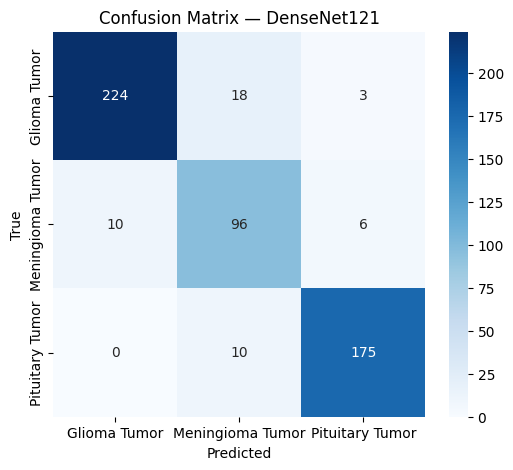

Fold: 1 block 5
17/17 ━━━━━━━━━━━━━━━━━━━━ 18s 373ms/step - accuracy: 0.9767 - loss: 0.0233
         Model      Loss  Accuracy
0  DenseNet121  0.033727  0.961255
17/17 ━━━━━━━━━━━━━━━━━━━━ 19s 599ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.98      0.98      0.98       245
Meningioma Tumor       0.90      0.93      0.91       112
 Pituitary Tumor       0.98      0.95      0.96       185

        accuracy                           0.96       542
       macro avg       0.95      0.95      0.95       542
    weighted avg       0.96      0.96      0.96       542



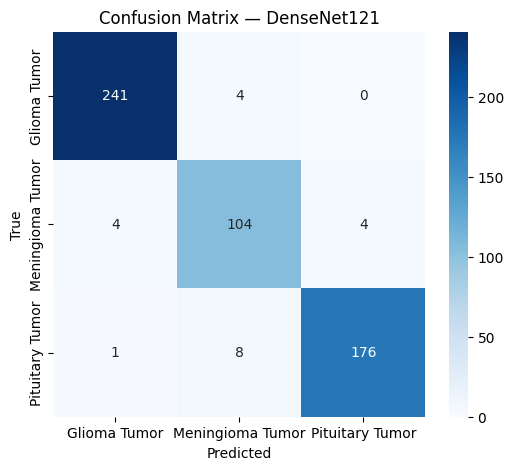

Fold: 1 block 4
17/17 ━━━━━━━━━━━━━━━━━━━━ 18s 378ms/step - accuracy: 0.9734 - loss: 0.0224
         Model      Loss  Accuracy
0  DenseNet121  0.031682   0.96679
17/17 ━━━━━━━━━━━━━━━━━━━━ 19s 612ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.96      0.98      0.97       245
Meningioma Tumor       0.93      0.91      0.92       112
 Pituitary Tumor       0.99      0.98      0.99       185

        accuracy                           0.97       542
       macro avg       0.96      0.96      0.96       542
    weighted avg       0.97      0.97      0.97       542



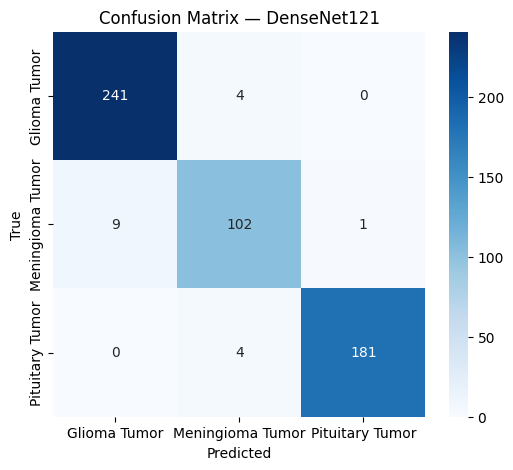

Fold: 1 block 3
17/17 ━━━━━━━━━━━━━━━━━━━━ 18s 381ms/step - accuracy: 0.9771 - loss: 0.0207
         Model      Loss  Accuracy
0  DenseNet121  0.024209   0.97417
17/17 ━━━━━━━━━━━━━━━━━━━━ 19s 596ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.98      0.98      0.98       245
Meningioma Tumor       0.96      0.92      0.94       112
 Pituitary Tumor       0.98      0.99      0.99       185

        accuracy                           0.97       542
       macro avg       0.97      0.97      0.97       542
    weighted avg       0.97      0.97      0.97       542



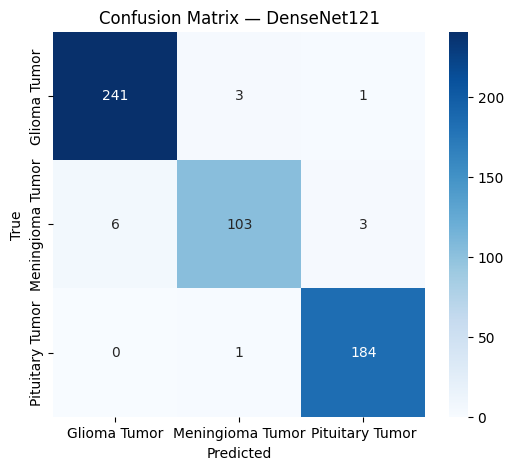

Fold: 1 block 2
17/17 ━━━━━━━━━━━━━━━━━━━━ 18s 376ms/step - accuracy: 0.9812 - loss: 0.0191
         Model      Loss  Accuracy
0  DenseNet121  0.021295  0.979705
17/17 ━━━━━━━━━━━━━━━━━━━━ 19s 597ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.99      0.98      0.99       245
Meningioma Tumor       0.94      0.97      0.96       112
 Pituitary Tumor       0.99      0.98      0.99       185

        accuracy                           0.98       542
       macro avg       0.97      0.98      0.98       542
    weighted avg       0.98      0.98      0.98       542



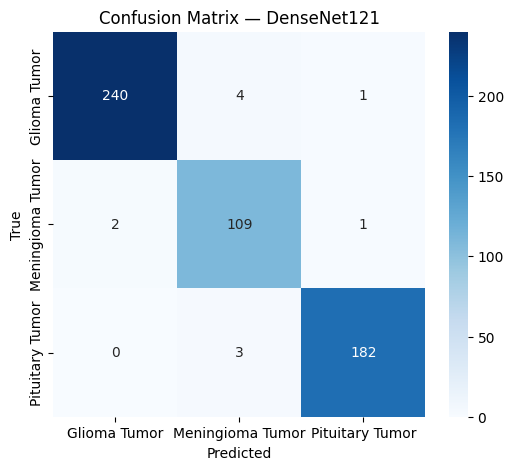

Fold: 1 block 1
17/17 ━━━━━━━━━━━━━━━━━━━━ 18s 387ms/step - accuracy: 0.9829 - loss: 0.0165
         Model      Loss  Accuracy
0  DenseNet121  0.022994   0.97417
17/17 ━━━━━━━━━━━━━━━━━━━━ 19s 611ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.98      0.98      0.98       245
Meningioma Tumor       0.93      0.97      0.95       112
 Pituitary Tumor       0.99      0.97      0.98       185

        accuracy                           0.97       542
       macro avg       0.97      0.97      0.97       542
    weighted avg       0.97      0.97      0.97       542



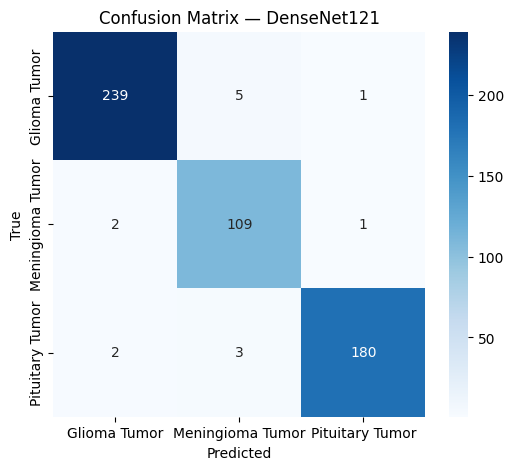

Fold: 2 block 6
Found 679 files belonging to 3 classes.
Found 542 files belonging to 3 classes.
Found 572 files belonging to 3 classes.
Found 628 files belonging to 3 classes.
Found 643 files belonging to 3 classes.
22/22 ━━━━━━━━━━━━━━━━━━━━ 23s 491ms/step - accuracy: 0.8708 - loss: 0.1204
         Model      Loss  Accuracy
0  DenseNet121  0.159718  0.830633
22/22 ━━━━━━━━━━━━━━━━━━━━ 21s 540ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.86      0.88      0.87       338
Meningioma Tumor       0.75      0.58      0.65       167
 Pituitary Tumor       0.84      0.97      0.90       174

        accuracy                           0.83       679
       macro avg       0.81      0.81      0.81       679
    weighted avg       0.83      0.83      0.82       679



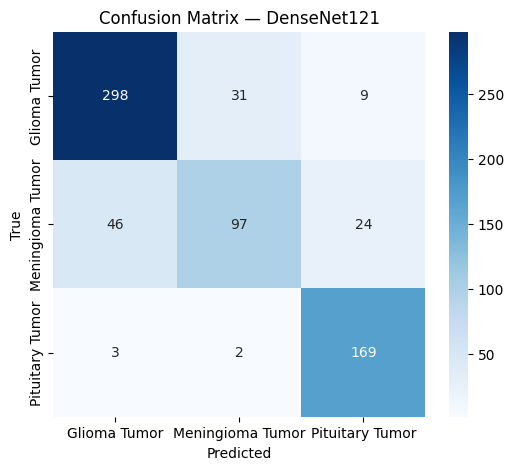

Fold: 2 block 5
22/22 ━━━━━━━━━━━━━━━━━━━━ 19s 307ms/step - accuracy: 0.8785 - loss: 0.1551
         Model      Loss  Accuracy
0  DenseNet121  0.187194  0.845361
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 483ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.88      0.88      0.88       338
Meningioma Tumor       0.76      0.67      0.71       167
 Pituitary Tumor       0.84      0.95      0.89       174

        accuracy                           0.85       679
       macro avg       0.83      0.83      0.83       679
    weighted avg       0.84      0.85      0.84       679



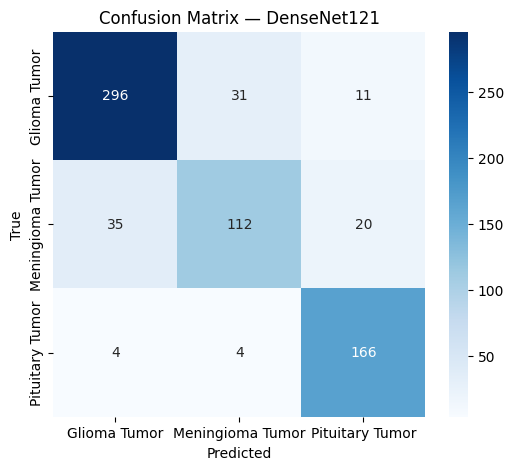

Fold: 2 block 4
22/22 ━━━━━━━━━━━━━━━━━━━━ 19s 306ms/step - accuracy: 0.9148 - loss: 0.1015
         Model      Loss  Accuracy
0  DenseNet121  0.125321   0.89838
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 481ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.93      0.92      0.92       338
Meningioma Tumor       0.89      0.77      0.83       167
 Pituitary Tumor       0.86      0.98      0.91       174

        accuracy                           0.90       679
       macro avg       0.89      0.89      0.89       679
    weighted avg       0.90      0.90      0.90       679



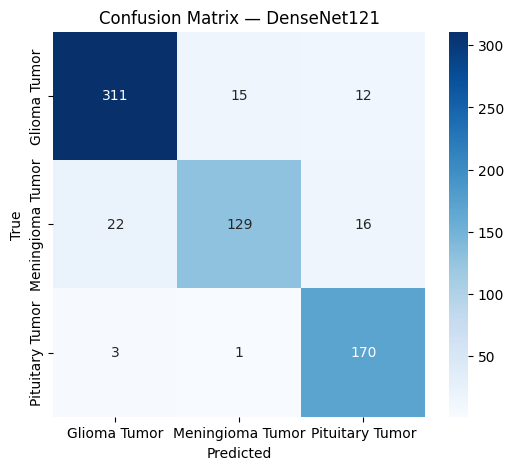

Fold: 2 block 3
22/22 ━━━━━━━━━━━━━━━━━━━━ 19s 304ms/step - accuracy: 0.9031 - loss: 0.1079
         Model      Loss  Accuracy
0  DenseNet121  0.135886  0.892489
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 479ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.92      0.91      0.92       338
Meningioma Tumor       0.91      0.75      0.82       167
 Pituitary Tumor       0.83      0.99      0.91       174

        accuracy                           0.89       679
       macro avg       0.89      0.88      0.88       679
    weighted avg       0.90      0.89      0.89       679



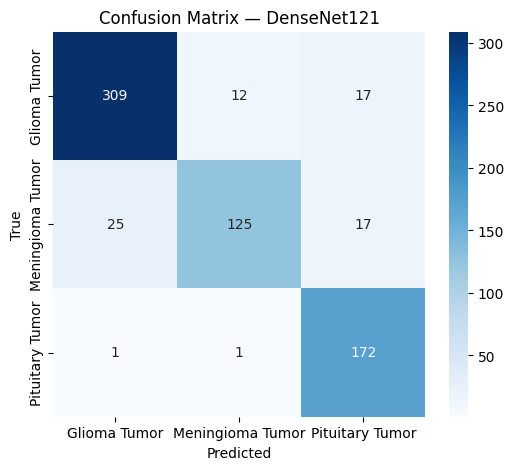

Fold: 2 block 2
22/22 ━━━━━━━━━━━━━━━━━━━━ 19s 306ms/step - accuracy: 0.9044 - loss: 0.1246
         Model      Loss  Accuracy
0  DenseNet121  0.139335  0.896907
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 482ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.93      0.90      0.91       338
Meningioma Tumor       0.85      0.83      0.84       167
 Pituitary Tumor       0.89      0.95      0.92       174

        accuracy                           0.90       679
       macro avg       0.89      0.89      0.89       679
    weighted avg       0.90      0.90      0.90       679



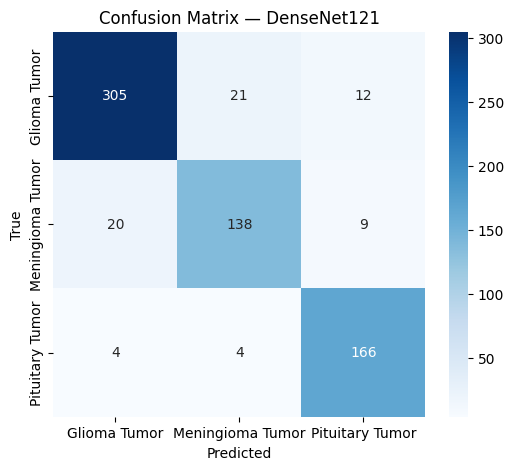

Fold: 2 block 1
22/22 ━━━━━━━━━━━━━━━━━━━━ 19s 307ms/step - accuracy: 0.8935 - loss: 0.1630
         Model      Loss  Accuracy
0  DenseNet121  0.162678  0.892489
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 480ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.95      0.86      0.91       338
Meningioma Tumor       0.79      0.87      0.83       167
 Pituitary Tumor       0.89      0.97      0.93       174

        accuracy                           0.89       679
       macro avg       0.88      0.90      0.89       679
    weighted avg       0.90      0.89      0.89       679



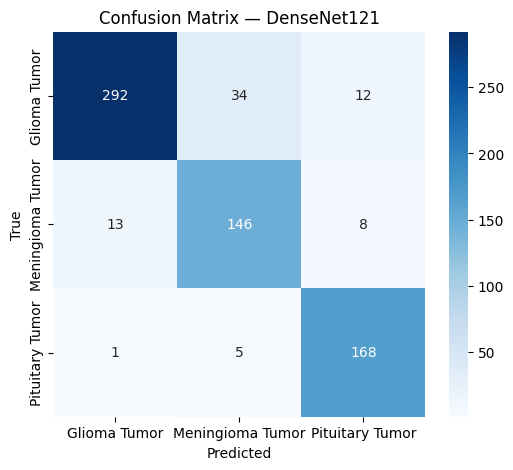

Fold: 3 block 6
Found 572 files belonging to 3 classes.
Found 542 files belonging to 3 classes.
Found 679 files belonging to 3 classes.
Found 628 files belonging to 3 classes.
Found 643 files belonging to 3 classes.
18/18 ━━━━━━━━━━━━━━━━━━━━ 24s 647ms/step - accuracy: 0.8896 - loss: 0.0965
         Model      Loss  Accuracy
0  DenseNet121  0.102983  0.888112
18/18 ━━━━━━━━━━━━━━━━━━━━ 21s 642ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.90      0.85      0.88       231
Meningioma Tumor       0.76      0.81      0.78       139
 Pituitary Tumor       0.97      0.99      0.98       202

        accuracy                           0.89       572
       macro avg       0.88      0.88      0.88       572
    weighted avg       0.89      0.89      0.89       572



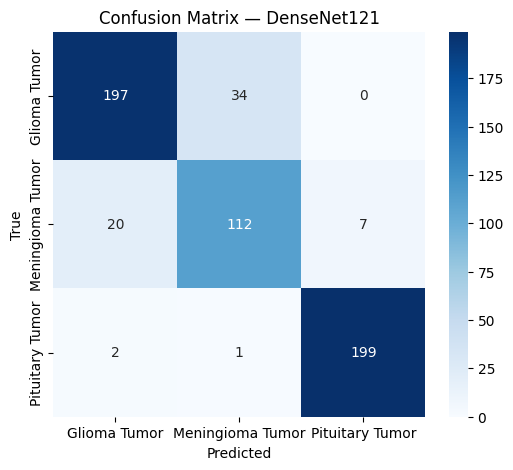

Fold: 3 block 5
18/18 ━━━━━━━━━━━━━━━━━━━━ 19s 367ms/step - accuracy: 0.8817 - loss: 0.1254
         Model      Loss  Accuracy
0  DenseNet121  0.124688  0.886364
18/18 ━━━━━━━━━━━━━━━━━━━━ 19s 578ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.91      0.87      0.89       231
Meningioma Tumor       0.80      0.76      0.78       139
 Pituitary Tumor       0.91      1.00      0.95       202

        accuracy                           0.89       572
       macro avg       0.87      0.87      0.87       572
    weighted avg       0.88      0.89      0.88       572



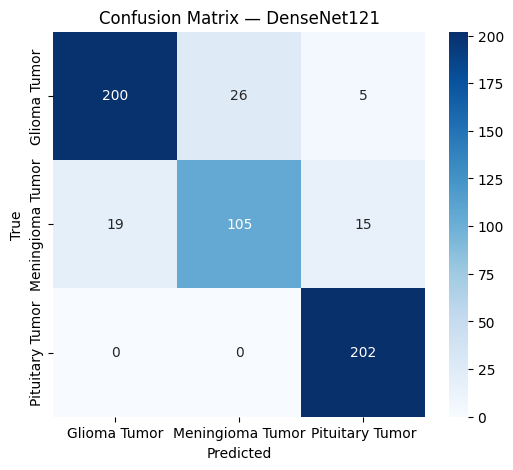

Fold: 3 block 4
18/18 ━━━━━━━━━━━━━━━━━━━━ 19s 360ms/step - accuracy: 0.9183 - loss: 0.0952
         Model      Loss  Accuracy
0  DenseNet121  0.097858  0.916084
18/18 ━━━━━━━━━━━━━━━━━━━━ 19s 574ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.95      0.89      0.92       231
Meningioma Tumor       0.84      0.84      0.84       139
 Pituitary Tumor       0.94      1.00      0.97       202

        accuracy                           0.92       572
       macro avg       0.91      0.91      0.91       572
    weighted avg       0.92      0.92      0.92       572



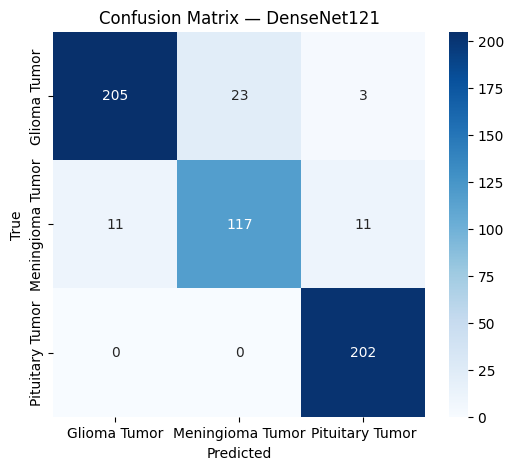

Fold: 3 block 3
18/18 ━━━━━━━━━━━━━━━━━━━━ 19s 366ms/step - accuracy: 0.8968 - loss: 0.1208
         Model     Loss  Accuracy
0  DenseNet121  0.12077   0.90035
18/18 ━━━━━━━━━━━━━━━━━━━━ 19s 577ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.95      0.85      0.90       231
Meningioma Tumor       0.79      0.84      0.82       139
 Pituitary Tumor       0.93      1.00      0.96       202

        accuracy                           0.90       572
       macro avg       0.89      0.90      0.89       572
    weighted avg       0.90      0.90      0.90       572



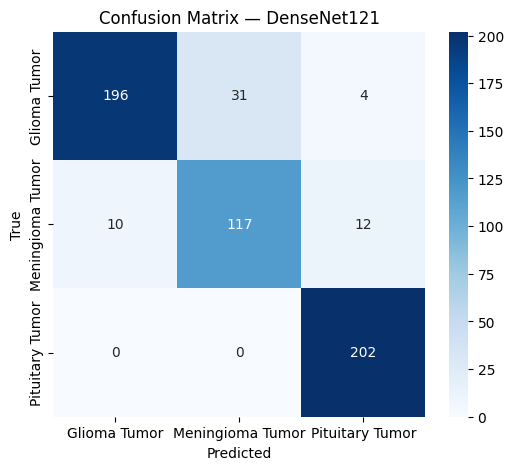

Fold: 3 block 2
18/18 ━━━━━━━━━━━━━━━━━━━━ 19s 364ms/step - accuracy: 0.9203 - loss: 0.1358
         Model      Loss  Accuracy
0  DenseNet121  0.135833  0.917832
18/18 ━━━━━━━━━━━━━━━━━━━━ 19s 577ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.97      0.86      0.91       231
Meningioma Tumor       0.79      0.90      0.84       139
 Pituitary Tumor       0.96      1.00      0.98       202

        accuracy                           0.92       572
       macro avg       0.91      0.92      0.91       572
    weighted avg       0.92      0.92      0.92       572



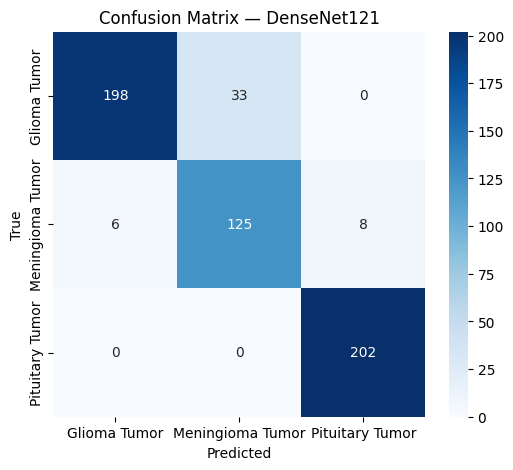

Fold: 3 block 1
18/18 ━━━━━━━━━━━━━━━━━━━━ 19s 365ms/step - accuracy: 0.9319 - loss: 0.0865
         Model      Loss  Accuracy
0  DenseNet121  0.103238  0.917832
18/18 ━━━━━━━━━━━━━━━━━━━━ 19s 581ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.89      0.95      0.92       231
Meningioma Tumor       0.90      0.76      0.82       139
 Pituitary Tumor       0.97      1.00      0.98       202

        accuracy                           0.92       572
       macro avg       0.92      0.90      0.91       572
    weighted avg       0.92      0.92      0.92       572



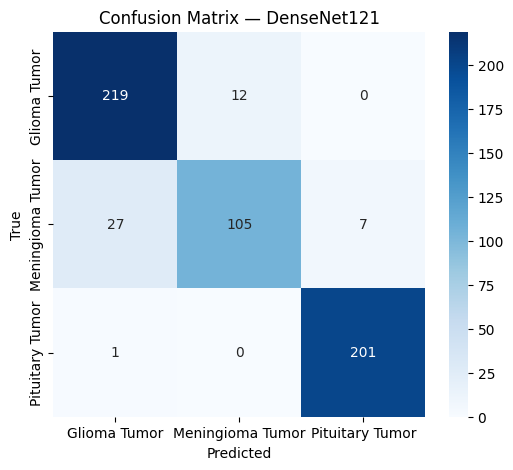

Fold: 4 block 6
Found 628 files belonging to 3 classes.
Found 542 files belonging to 3 classes.
Found 679 files belonging to 3 classes.
Found 572 files belonging to 3 classes.
Found 643 files belonging to 3 classes.
20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 557ms/step - accuracy: 0.8940 - loss: 0.1030
         Model      Loss  Accuracy
0  DenseNet121  0.107539  0.886943
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 581ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.94      0.88      0.91       325
Meningioma Tumor       0.71      0.80      0.75       124
 Pituitary Tumor       0.92      0.96      0.94       179

        accuracy                           0.89       628
       macro avg       0.86      0.88      0.87       628
    weighted avg       0.89      0.89      0.89       628



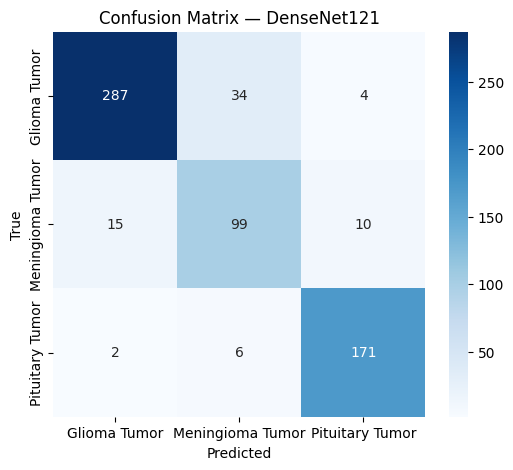

Fold: 4 block 5
20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 334ms/step - accuracy: 0.9559 - loss: 0.0461
         Model      Loss  Accuracy
0  DenseNet121  0.064808  0.931529
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 528ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.96      0.97      0.97       325
Meningioma Tumor       0.89      0.78      0.83       124
 Pituitary Tumor       0.90      0.97      0.93       179

        accuracy                           0.93       628
       macro avg       0.92      0.91      0.91       628
    weighted avg       0.93      0.93      0.93       628



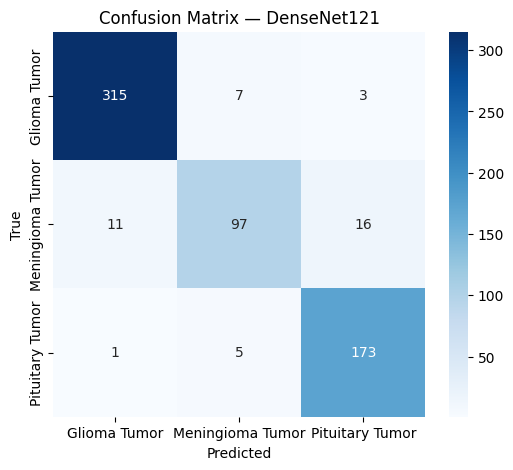

Fold: 4 block 4
20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 337ms/step - accuracy: 0.9585 - loss: 0.0387
         Model      Loss  Accuracy
0  DenseNet121  0.062591  0.933121
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 524ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.96      0.98      0.97       325
Meningioma Tumor       0.90      0.77      0.83       124
 Pituitary Tumor       0.90      0.97      0.93       179

        accuracy                           0.93       628
       macro avg       0.92      0.90      0.91       628
    weighted avg       0.93      0.93      0.93       628



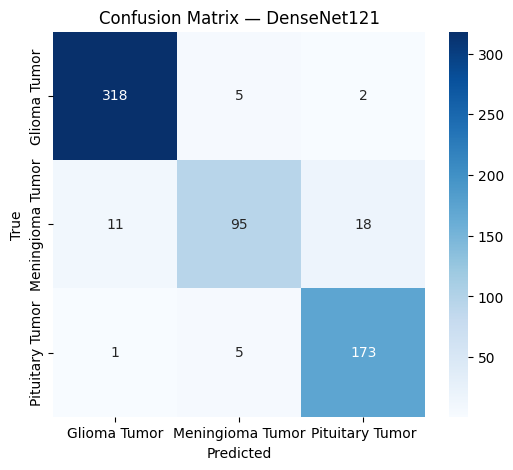

Fold: 4 block 3
20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 331ms/step - accuracy: 0.9666 - loss: 0.0288
         Model      Loss  Accuracy
0  DenseNet121  0.051408  0.947452
20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 523ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.98      0.98      0.98       325
Meningioma Tumor       0.94      0.81      0.87       124
 Pituitary Tumor       0.89      0.97      0.93       179

        accuracy                           0.95       628
       macro avg       0.94      0.92      0.93       628
    weighted avg       0.95      0.95      0.95       628



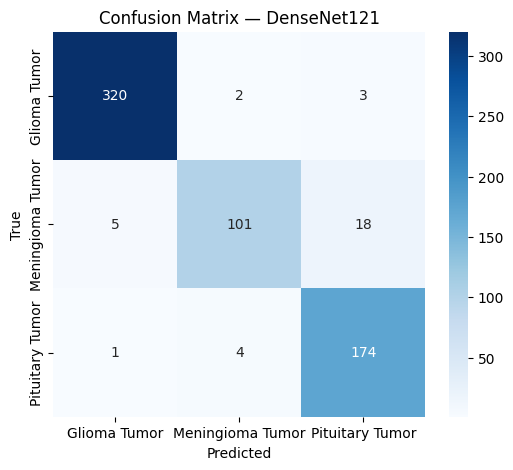

Fold: 4 block 2
20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 333ms/step - accuracy: 0.9772 - loss: 0.0300
         Model      Loss  Accuracy
0  DenseNet121  0.056205  0.955414
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 528ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.99      1.00      0.99       325
Meningioma Tumor       0.94      0.83      0.88       124
 Pituitary Tumor       0.91      0.97      0.94       179

        accuracy                           0.96       628
       macro avg       0.95      0.93      0.94       628
    weighted avg       0.96      0.96      0.95       628



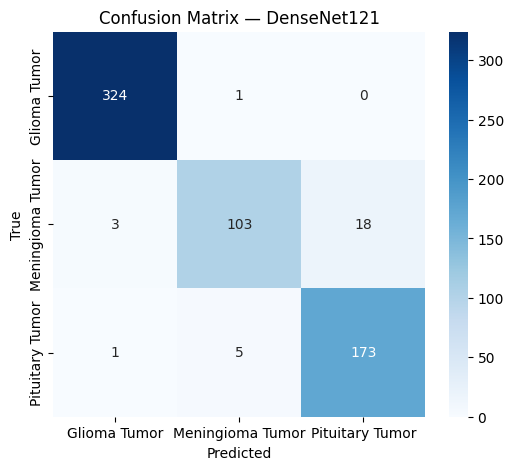

Fold: 4 block 1
20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 329ms/step - accuracy: 0.9698 - loss: 0.0343
         Model      Loss  Accuracy
0  DenseNet121  0.065429  0.942675
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 523ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.97      1.00      0.98       325
Meningioma Tumor       0.97      0.75      0.85       124
 Pituitary Tumor       0.89      0.97      0.93       179

        accuracy                           0.94       628
       macro avg       0.94      0.91      0.92       628
    weighted avg       0.94      0.94      0.94       628



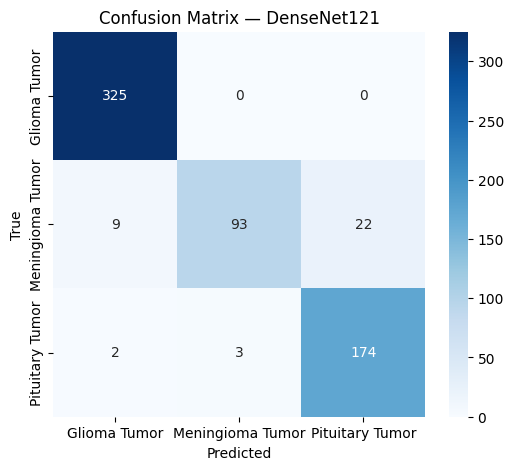

Fold: 5 block 6
Found 643 files belonging to 3 classes.
Found 542 files belonging to 3 classes.
Found 679 files belonging to 3 classes.
Found 572 files belonging to 3 classes.
Found 628 files belonging to 3 classes.
21/21 ━━━━━━━━━━━━━━━━━━━━ 22s 473ms/step - accuracy: 0.7863 - loss: 0.2319
         Model      Loss  Accuracy
0  DenseNet121  0.245448  0.797823
21/21 ━━━━━━━━━━━━━━━━━━━━ 20s 529ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.90      0.83      0.86       287
Meningioma Tumor       0.70      0.52      0.60       166
 Pituitary Tumor       0.74      0.99      0.85       190

        accuracy                           0.80       643
       macro avg       0.78      0.78      0.77       643
    weighted avg       0.80      0.80      0.79       643



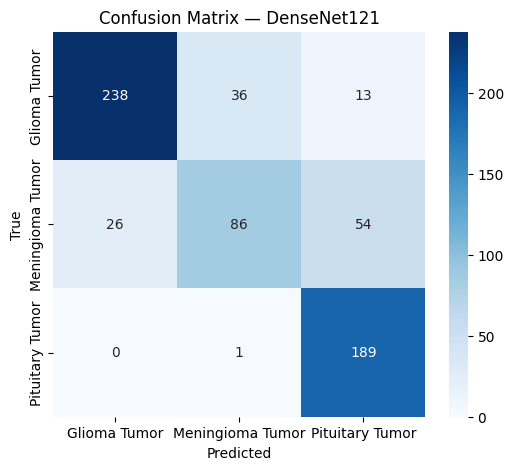

Fold: 5 block 5
21/21 ━━━━━━━━━━━━━━━━━━━━ 19s 303ms/step - accuracy: 0.8366 - loss: 0.2506
         Model     Loss  Accuracy
0  DenseNet121  0.29437  0.835148
21/21 ━━━━━━━━━━━━━━━━━━━━ 19s 487ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.93      0.86      0.89       287
Meningioma Tumor       0.74      0.60      0.66       166
 Pituitary Tumor       0.79      0.99      0.88       190

        accuracy                           0.84       643
       macro avg       0.82      0.82      0.81       643
    weighted avg       0.84      0.84      0.83       643



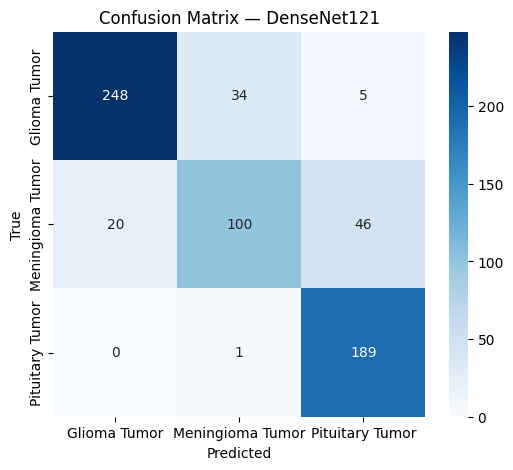

Fold: 5 block 4
21/21 ━━━━━━━━━━━━━━━━━━━━ 19s 305ms/step - accuracy: 0.8526 - loss: 0.2567
         Model      Loss  Accuracy
0  DenseNet121  0.317079  0.842924
21/21 ━━━━━━━━━━━━━━━━━━━━ 19s 486ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.93      0.90      0.91       287
Meningioma Tumor       0.80      0.58      0.67       166
 Pituitary Tumor       0.77      0.99      0.87       190

        accuracy                           0.84       643
       macro avg       0.83      0.82      0.82       643
    weighted avg       0.85      0.84      0.84       643



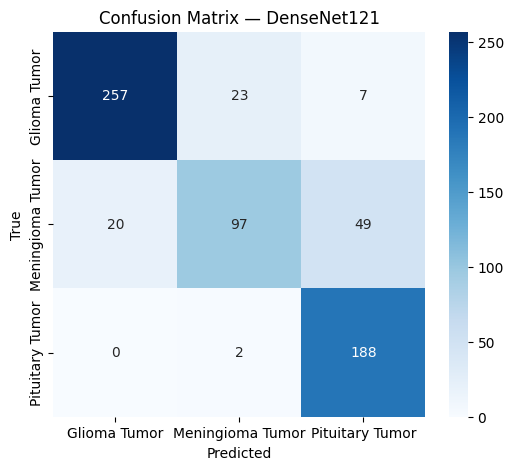

Fold: 5 block 3
21/21 ━━━━━━━━━━━━━━━━━━━━ 19s 305ms/step - accuracy: 0.8494 - loss: 0.2408
         Model      Loss  Accuracy
0  DenseNet121  0.306583    0.8507
21/21 ━━━━━━━━━━━━━━━━━━━━ 19s 488ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.93      0.89      0.91       287
Meningioma Tumor       0.81      0.61      0.69       166
 Pituitary Tumor       0.78      1.00      0.88       190

        accuracy                           0.85       643
       macro avg       0.84      0.83      0.83       643
    weighted avg       0.86      0.85      0.85       643



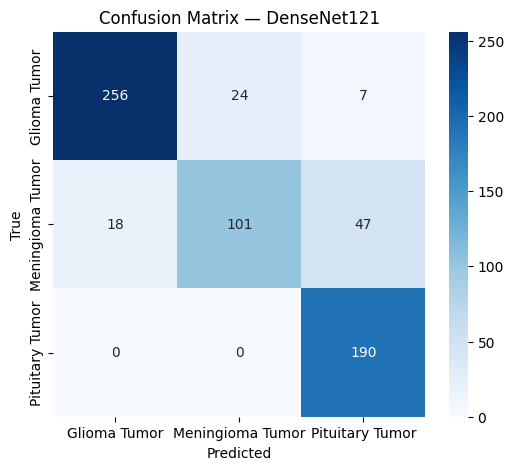

Fold: 5 block 2
21/21 ━━━━━━━━━━━━━━━━━━━━ 19s 301ms/step - accuracy: 0.8802 - loss: 0.2735
         Model      Loss  Accuracy
0  DenseNet121  0.355965  0.858476
21/21 ━━━━━━━━━━━━━━━━━━━━ 19s 483ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.93      0.91      0.92       287
Meningioma Tumor       0.82      0.61      0.70       166
 Pituitary Tumor       0.80      1.00      0.89       190

        accuracy                           0.86       643
       macro avg       0.85      0.84      0.83       643
    weighted avg       0.86      0.86      0.85       643



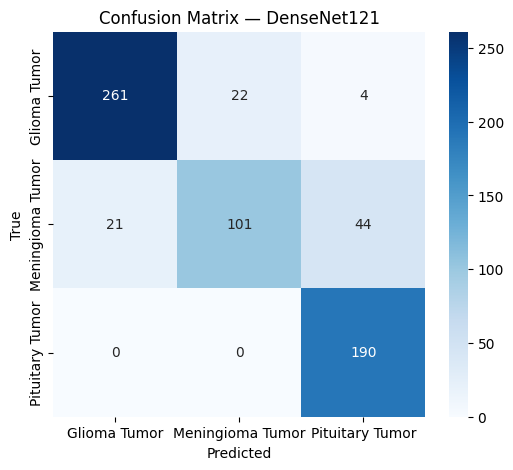

Fold: 5 block 1
21/21 ━━━━━━━━━━━━━━━━━━━━ 19s 304ms/step - accuracy: 0.8854 - loss: 0.2724
         Model      Loss  Accuracy
0  DenseNet121  0.330909  0.874028
21/21 ━━━━━━━━━━━━━━━━━━━━ 19s 484ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.98      0.88      0.93       287
Meningioma Tumor       0.80      0.72      0.76       166
 Pituitary Tumor       0.80      0.99      0.89       190

        accuracy                           0.87       643
       macro avg       0.86      0.87      0.86       643
    weighted avg       0.88      0.87      0.87       643



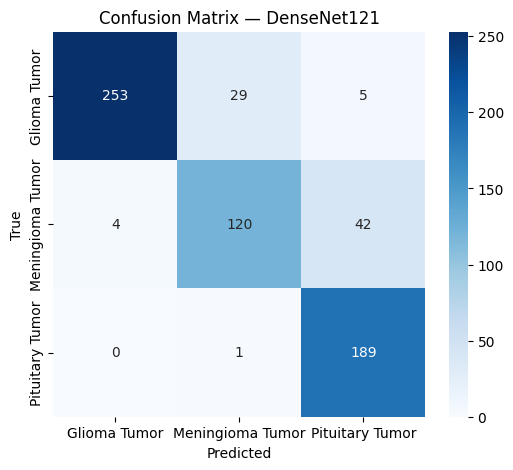

In [18]:
for fold_k in range(1, 6):
    print(f'Fold: {fold_k} block 6')
    train_ds, val_ds = get_data_for_fold(fold_k, preprocess_fn)
    
    acc_b6.append(test_classifier(train_ds, val_ds, preprocess_fn, fold_k))
    tf.keras.backend.clear_session()
    gc.collect()

    for block in range(5, 0, -1):
        print(f'Fold: {fold_k} block {block}')
        acc_list = [None, acc_b1, acc_b2, acc_b3, acc_b4, acc_b5]
        acc_list[block].append(test_block(train_ds, val_ds, preprocess_fn, fold_k, block))
        tf.keras.backend.clear_session()
        gc.collect()
    
    del train_ds, val_ds
    gc.collect()

In [19]:
ACC_BLOCK = [acc_b6, acc_b5, acc_b4, acc_b3, acc_b2, acc_b1]
ACC_BLOCK

[[0.9132841229438782,
  0.830633282661438,
  0.8881118893623352,
  0.8869426846504211,
  0.7978227138519287],
 [0.9612545967102051,
  0.8453608155250549,
  0.8863636255264282,
  0.9315286874771118,
  0.8351477384567261],
 [0.9667896628379822,
  0.8983799815177917,
  0.9160839319229126,
  0.9331210255622864,
  0.8429238200187683],
 [0.9741697311401367,
  0.892488956451416,
  0.9003496766090393,
  0.9474522471427917,
  0.8506998419761658],
 [0.9797047972679138,
  0.8969072103500366,
  0.9178321957588196,
  0.9554139971733093,
  0.858475923538208],
 [0.9741697311401367,
  0.892488956451416,
  0.9178321957588196,
  0.9426751732826233,
  0.8740279674530029]]

In [20]:
for _, acc in enumerate(ACC_BLOCK):
    print(f'Accuracy unfreeze block {6 - _} - block 6: {np.mean(acc) * 100:.2f}%')

Accuracy unfreeze block 6 - block 6: 86.34%
Accuracy unfreeze block 5 - block 6: 89.19%
Accuracy unfreeze block 4 - block 6: 91.15%
Accuracy unfreeze block 3 - block 6: 91.30%
Accuracy unfreeze block 2 - block 6: 92.17%
Accuracy unfreeze block 1 - block 6: 92.02%
